In [2]:
import io
import os
import pandas as pd
import gzip as gz
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker
sns.set_theme(font="Arial", font_scale=1.15, style='ticks')
plt.rc("axes.spines", top=False, right=False)

def read_vcf(path):
    with gz.open(path, 'rb') as f:
        lines = [l.decode('utf-8') for l in f if not l.startswith(b'##')]
    return pd.read_csv(
        io.StringIO(''.join(lines)),
        dtype={'#CHROM': str, 'POS': int, 'ID': str, 'REF': str, 'ALT': str,
               'QUAL': str, 'FILTER': str, 'INFO': str},
        sep='\t'
    ).rename(columns={'#CHROM': 'CHROM'})

dir1="/Users/mhryansohn/Desktop/01.Workspace/02.Institution/04.UW/Variant_Truset/VariantCalls_DeepVariant_1.6.1/COLO829BL"
dir2="/Users/mhryansohn/Desktop/01.Workspace/02.Institution/04.UW/Variant_Truset/VariantCalls_DeepVariant_1.6.1/COLO829T/PassageB"
dir3="/Users/mhryansohn/Desktop/01.Workspace/02.Institution/04.UW/Variant_Truset/VariantCalls_DeepVariant_1.6.1/COLO829T/PassageA"

In [3]:
colobl_vcf = read_vcf(f"{dir1}/COLO829BL.deepvariant.vcf.gz")
colotb_vcf = read_vcf(f"{dir2}/COLO829T_PassageB_DSA.deepvariant.vcf.gz")
colota_vcf = read_vcf(f"{dir3}/COLO829T_PassageA_DSA.deepvariant.vcf.gz")

In [4]:
colobl_vcf

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,COLO829BL
0,haplotype1-0000001,184,.,TC,T,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:50:10:8,2:0.2:0,50,56"
1,haplotype1-0000001,922,.,GC,G,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:55:15:13,2:0.133333:0,58,58"
2,haplotype1-0000001,1901,.,A,AG,45.6,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/1:21:24:4,19:0.791667:45,20,0"
3,haplotype1-0000001,2332,.,TG,T,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:51:29:24,5:0.172414:0,52,56"
4,haplotype1-0000001,9933,.,CA,C,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:62:98:83,14:0.142857:0,67,63"
...,...,...,...,...,...,...,...,...,...,...
3790198,haplotype2-0000195,32443,.,AT,A,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:52:39:34,5:0.128205:0,53,56"
3790199,haplotype2-0000195,35992,.,AT,A,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:40:28:21,7:0.25:0,40,54"
3790200,haplotype2-0000195,42009,.,AT,A,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:53:13:11,2:0.153846:0,54,57"
3790201,haplotype2-0000195,43080,.,AT,A,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:37:11:6,5:0.454545:0,37,50"


In [5]:
print(f"COLO829BL PASS variants from all tested alleles: {round(colobl_vcf[colobl_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colobl_vcf.index.shape[0], 2)} %")
print(f"COLO829BL PASS SNVs from all tested SNV alleles: {round(colobl_vcf[(colobl_vcf['FILTER'] == 'PASS') & (colobl_vcf['REF'].str.len() == 1) & (colobl_vcf['ALT'].str.len() == 1)].index.shape[0]*100 / colobl_vcf[((colobl_vcf['REF']).str.len() ==1) & (colobl_vcf['ALT'].str.len()==1)].index.shape[0], 2)} %")

print(f"COLO829T (Passage B) PASS variants from all tested alleles: {round(colotb_vcf[colotb_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colotb_vcf.index.shape[0], 2)} %")
print(f"COLO829T (Passage B) PASS SNVs from all tested SNV alleles: {round(colotb_vcf[(colotb_vcf['FILTER'] == 'PASS') & (colotb_vcf['REF'].str.len() == 1) & (colotb_vcf['ALT'].str.len() == 1)].index.shape[0]*100 / colotb_vcf[((colotb_vcf['REF']).str.len() ==1) & (colotb_vcf['ALT'].str.len()==1)].index.shape[0], 2)} %")

print(f"COLO829T (Passage A) PASS variants from all tested alleles: {round(colota_vcf[colota_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colota_vcf.index.shape[0], 2)} %")
print(f"COLO829T (Passage A) PASS SNVs from all tested SNV alleles: {round(colota_vcf[(colota_vcf['FILTER'] == 'PASS') & (colota_vcf['REF'].str.len() == 1) & (colota_vcf['ALT'].str.len() == 1)].index.shape[0]*100 / colota_vcf[((colota_vcf['REF']).str.len() ==1) & (colota_vcf['ALT'].str.len()==1)].index.shape[0], 2)} %")

COLO829BL PASS variants from all tested alleles: 5.16 %
COLO829BL PASS SNVs from all tested SNV alleles: 13.66 %
COLO829T (Passage B) PASS variants from all tested alleles: 10.29 %
COLO829T (Passage B) PASS SNVs from all tested SNV alleles: 20.81 %
COLO829T (Passage A) PASS variants from all tested alleles: 7.73 %
COLO829T (Passage A) PASS SNVs from all tested SNV alleles: 22.33 %


In [6]:
colobl_snvs = colobl_vcf[(colobl_vcf['FILTER'] == 'PASS') & (colobl_vcf['REF'].str.len() == 1) & (colobl_vcf['ALT'].str.len() == 1)]
colotb_snvs = colotb_vcf[(colotb_vcf['FILTER'] == 'PASS') & (colotb_vcf['REF'].str.len() == 1) & (colotb_vcf['ALT'].str.len() == 1)]
colota_snvs = colota_vcf[(colota_vcf['FILTER'] == 'PASS') & (colota_vcf['REF'].str.len() == 1) & (colota_vcf['ALT'].str.len() == 1)]

colobl_snvs_refcall = colobl_vcf[(colobl_vcf['FILTER'] == 'RefCall') & (colobl_vcf['REF'].str.len() == 1) & (colobl_vcf['ALT'].str.len() == 1)]
colotb_snvs_refcall = colotb_vcf[(colotb_vcf['FILTER'] == 'RefCall') & (colotb_vcf['REF'].str.len() == 1) & (colotb_vcf['ALT'].str.len() == 1)]
colota_snvs_refcall = colota_vcf[(colota_vcf['FILTER'] == 'RefCall') & (colota_vcf['REF'].str.len() == 1) & (colota_vcf['ALT'].str.len() == 1)]

In [12]:
vafindex = list(set(colobl_snvs['FORMAT'].values))[0].split(':').index('VAF')
dpindex = list(set(colobl_snvs['FORMAT'].values))[0].split(':').index('DP')

In [8]:
'''
stat
-count: show the number of observations in each bin
-frequency: show the number of observations divided by the bin width
-probability or proportion: normalize such that bar heights sum to 1
-percent: normalize such that bar heights sum to 100
-density: normalize such that the total area of the histogram equals 1
'''

'\nstat\n-count: show the number of observations in each bin\n-frequency: show the number of observations divided by the bin width\n-probability or proportion: normalize such that bar heights sum to 1\n-percent: normalize such that bar heights sum to 100\n-density: normalize such that the total area of the histogram equals 1\n'

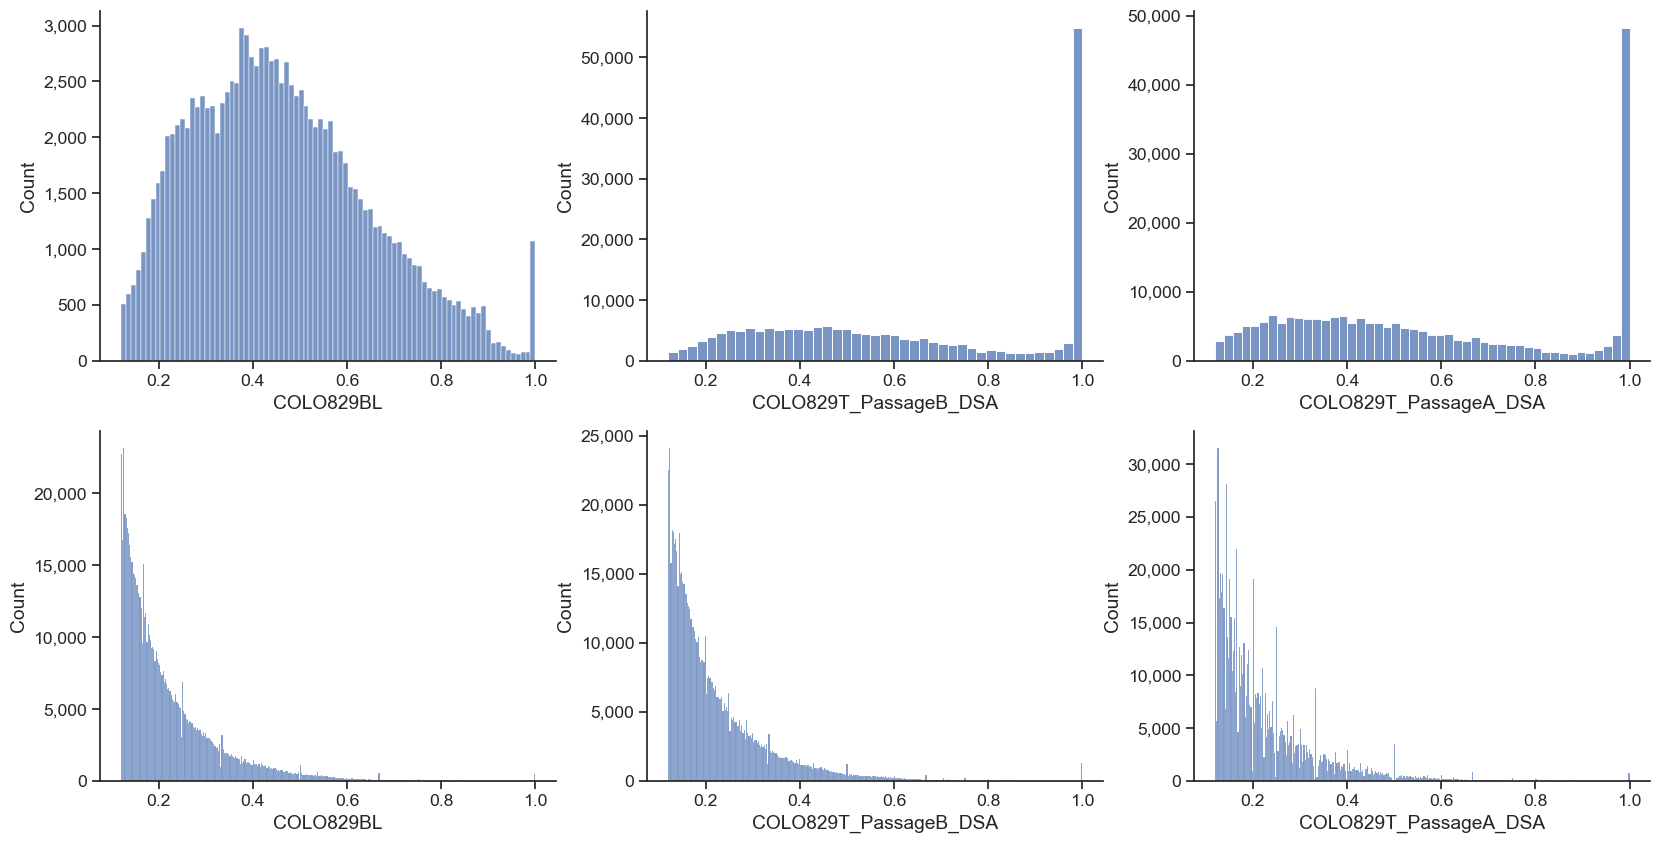

In [9]:
fig, axes = plt.subplots(2,3, figsize=(20,10))
sns.histplot(colobl_snvs['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0,0])
axes[0,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0,1])
axes[0,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0,2])
axes[0,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.histplot(colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1,0])
axes[1,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1,1])
axes[1,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1,2])
axes[1,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))



In [18]:
print(f"Minimum VAF for PASS SNVs in COLO829BL: {colobl_snvs['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for PASS SNVs  in COLO829T (Passage B): {colotb_snvs['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for PASS SNVs  in COLO829T (Passage A): {colota_snvs['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")

print(f"Minimum VAF for RefCall SNVs in COLO829BL: {colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for RefCall SNVs  in COLO829T (Passage B): {colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for RefCall SNVs  in COLO829T (Passage A): {colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")

Minimum VAF for PASS SNVs in COLO829BL: 0.12
Minimum VAF for PASS SNVs  in COLO829T (Passage B): 0.12
Minimum VAF for PASS SNVs  in COLO829T (Passage A): 0.12
Minimum VAF for RefCall SNVs in COLO829BL: 0.12
Minimum VAF for RefCall SNVs  in COLO829T (Passage B): 0.12
Minimum VAF for RefCall SNVs  in COLO829T (Passage A): 0.12


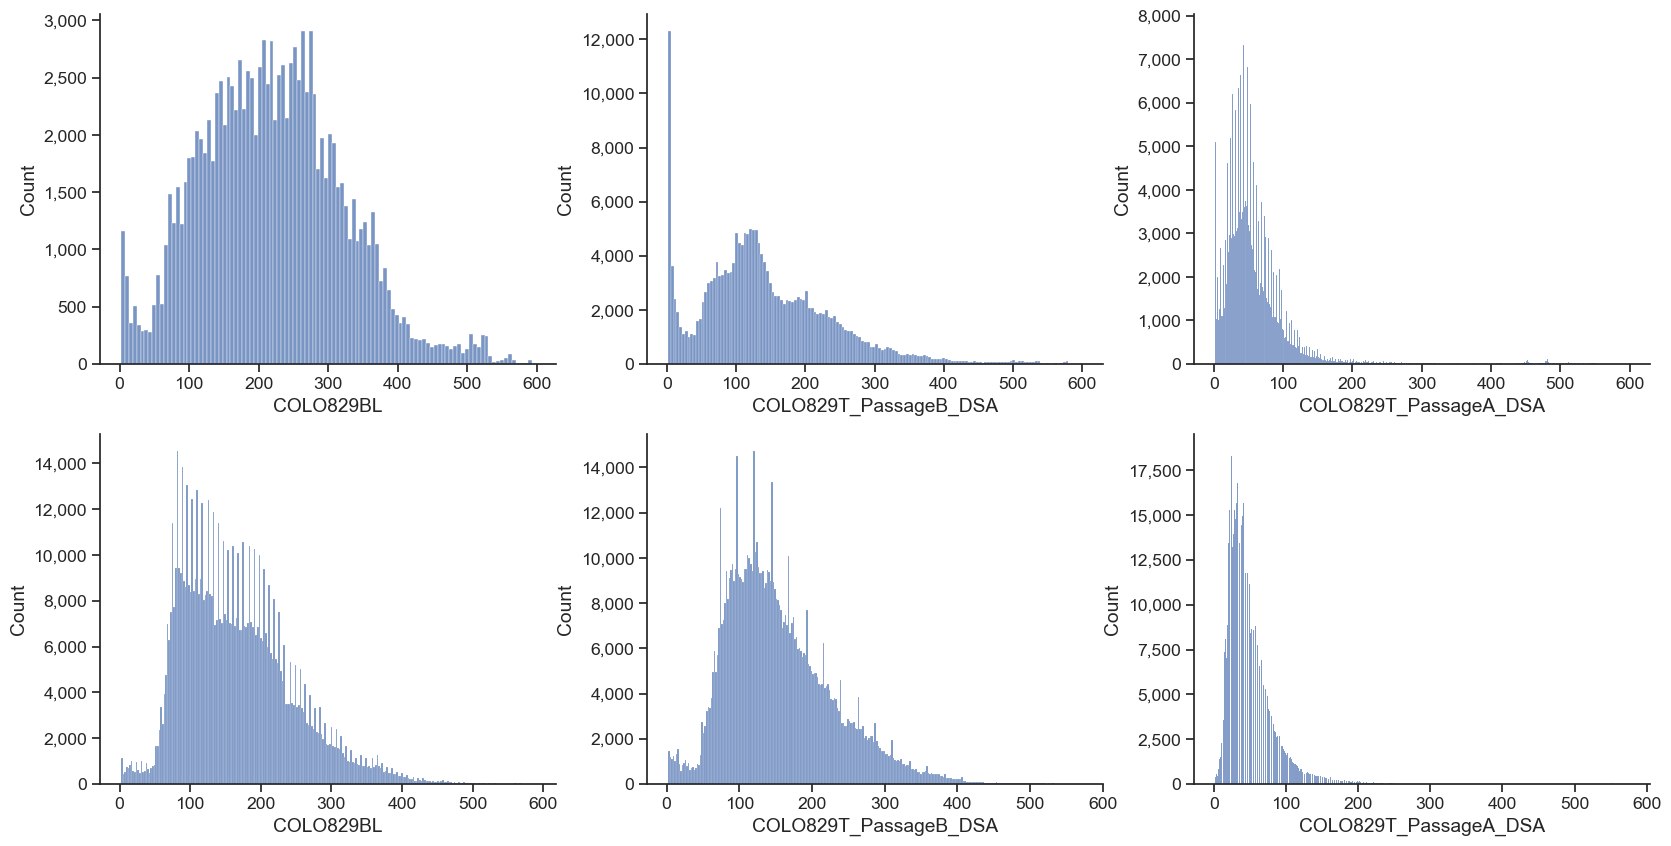

In [16]:
fig, axes = plt.subplots(2,3, figsize=(20,10))
sns.histplot(colobl_snvs['COLO829BL'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[0,0])
axes[0,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[0,1])
axes[0,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[0,2])
axes[0,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.histplot(colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[1,0])
axes[1,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[1,1])
axes[1,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[1,2])
axes[1,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))



In [14]:
colobl_snvs['COLO829BL'].str.split(':').apply(lambda x: float(x[dpindex]))

34         190.0
958        123.0
1606       175.0
2988       200.0
3113       161.0
           ...  
3790191     56.0
3790192     56.0
3790194     55.0
3790195     55.0
3790196     54.0
Name: COLO829BL, Length: 123234, dtype: float64